In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [20]:
train_path = "/content/drive/MyDrive/classification_task/train"
test_path  = "/content/drive/MyDrive/classification_task/test"

In [44]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.


In [45]:
def channel_attention(x, ratio=8):
    channels = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Dense(channels//ratio, activation='relu')(avg_pool)
    avg_pool = Dense(channels, activation='sigmoid')(avg_pool)
    avg_pool = Reshape((1,1,channels))(avg_pool)

    return Multiply()([x, avg_pool])

In [46]:
def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(x)

    concat = Concatenate(axis=3)([avg_pool, max_pool])
    spatial = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, spatial])

In [47]:
class SelfAttention(Layer):
    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.query = Conv2D(self.channels//8, 1, padding='same')
        self.key   = Conv2D(self.channels//8, 1, padding='same')
        self.value = Conv2D(self.channels, 1, padding='same')
        self.gamma = self.add_weight(shape=[1], initializer='zeros', trainable=True)

    def call(self, x):
        batch = tf.shape(x)[0]
        h = tf.shape(x)[1]
        w = tf.shape(x)[2]
        c = tf.shape(x)[3]

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = tf.reshape(q, [batch, h*w, c//8])
        k = tf.reshape(k, [batch, h*w, c//8])
        v = tf.reshape(v, [batch, h*w, c])

        attention = tf.matmul(q, k, transpose_b=True)
        attention = tf.nn.softmax(attention)

        out = tf.matmul(attention, v)
        out = tf.reshape(out, [batch, h, w, c])

        return self.gamma * out + x

In [48]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tune last 30 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

x = base_model.output   # 7x7x2048

# Apply attention
x = channel_attention(x)
x = spatial_attention(x)
x = SelfAttention()(x)

x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [49]:
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 350ms/step - accuracy: 0.7872 - loss: 0.5391 - val_accuracy: 0.7345 - val_loss: 0.8727 - learning_rate: 3.0000e-05
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 349ms/step - accuracy: 0.8204 - loss: 0.4636 - val_accuracy: 0.6533 - val_loss: 1.0964 - learning_rate: 3.0000e-05
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 342ms/step - accuracy: 0.8223 - loss: 0.4394 - val_accuracy: 0.6914 - val_loss: 0.9386 - learning_rate: 3.0000e-05
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 103s 410ms/step - accuracy: 0.8291 - loss: 0.4326 - val_accuracy: 0.7194 - val_loss: 0.7855 - learning_rate: 3.0000e-05
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 345ms/step - accuracy: 0.8496 - loss: 0.3830 - val_accuracy: 0.8126 - val_loss: 0.7165 - learning_rate: 3.0000e-05


In [52]:
loss, acc = model.evaluate(test_gen)
print("Overall Test Accuracy: {:.2f}%".format(acc*100))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.6850 - loss: 0.9711
Overall Test Accuracy: 77.00%


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step


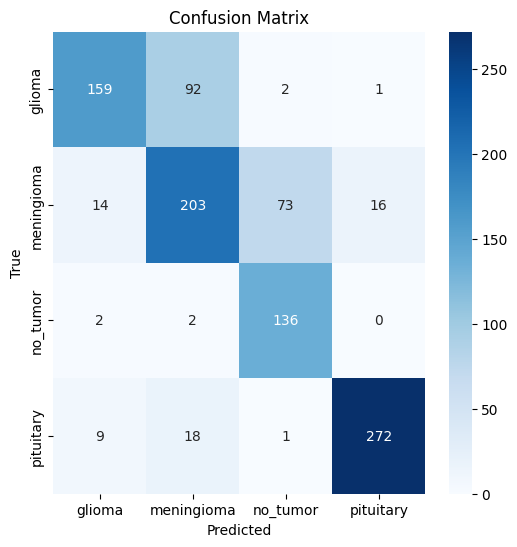


Classification Report:

              precision    recall  f1-score   support

      glioma       0.86      0.63      0.73       254
  meningioma       0.64      0.66      0.65       306
    no_tumor       0.64      0.97      0.77       140
   pituitary       0.94      0.91      0.92       300

    accuracy                           0.77      1000
   macro avg       0.77      0.79      0.77      1000
weighted avg       0.79      0.77      0.77      1000



In [55]:
test_gen.reset()

pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

class_labels = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))